VERSION 2023/04/09
- ** FIX H **

In [ ]:
import numpy as np
import tensorflow as tf
import math
import matplotlib.pyplot as plt

1) Set all parameters

In [ ]:
No_bit = 800
test_size = 1000000
Tx = 5
Rx = 1
SNR_db = np.arange(70, 125, 5)
#SNR_db = np.array([70,100,130]) #70
BER_u1 = np.zeros(len(SNR_db))
BER_u2 = np.zeros(len(SNR_db))

d1 = 0.015   #Distance from BS to UE1 in km == 15 m.
d2 = 0.005 #Distance from BS to UE2 in km -- 5 m.
f = 2.4 #Carrier frequency in GHz
a1 = 0.8  #Power allocation of user1
a2 = 0.2  #Power allocation of user2

2) Path Loss Calculation

In [ ]:
#Generate channel for user 1
Lp1_dB = 92.4 + 20*math.log10(f) + 20*math.log10(d1) #Large scale for user2 in dB
Lp1 = pow(10,(Lp1_dB/10)); #Large scale in Linear

#Generate channel
Lp2_dB = 92.4 + 20*math.log10(f) + 20*math.log10(d2) #Large scale for user2 in dB
Lp2 = pow(10,(Lp2_dB/10)); #Large scale in Linear


3) Generate Rayleigh Channel Coef

In [ ]:
  #h_real_ran = (np.random.randn(Tx, 1, No_bit))
  #h_real_m = np.mean(h_real_ran, axis = 2)
  #h_real = np.sum(h_real_m, axis = 0)

In [ ]:
def channel_generate(Tx, Rx, No_bit):
  #h_real_ran = (np.random.randn(Tx, Rx, No_bit))
  #h_real_m = np.mean(h_real_ran, axis = 2)
  h_real_m = 0.5
  h_real = np.sum(h_real_m, axis = 0)

  #h_imag_ran = (np.random.randn(Tx, Rx, No_bit))
  #h_imag_m = np.mean(h_imag_ran, axis = 2)
  h_imag_m = 0.5
  h_imag = np.sum(h_imag_m, axis = 0)

  return h_real, h_imag

4) Generate random binary data vector for two users with size  

In [ ]:
#Gen data size following no of Rx
def data_generate(No_bit):
    data = np.random.randint(0, 2, size=(No_bit,1))

    #label = data.reshape(len(data), 1)
    #label = tf.keras.utils.to_categorical(label)

    return data

5) Do BPSK modulation of data

6) Do superposition coding

In [ ]:
def SPC_generate(No_bit):
  data_r1 = data_generate(No_bit)
  data_r2 = data_generate(No_bit)

  symbol_r1 = 2*data_r1 - 1
  symbol_r2 = 2*data_r2 - 1

  label_r1 = data_r1
  label_r2 = data_r2

  #label_r1 = label_u1.reshape(No_bit, 1)
  #label_r2 = label_u2.reshape(No_bit, 1)

  SPC = math.sqrt(a1)*symbol_r1 + math.sqrt(a2)*symbol_r2

  return SPC, label_r1, label_r2

7) Generate noise samples and channel coef for each received antenna.

In [ ]:
def noise_generate(Rx, No_bit):
  w_real = (np.random.randn(No_bit, Rx))
  w_real = w_real / math.sqrt(2)

  w_imag = (np.random.randn(No_bit, Rx))
  w_imag =  w_imag / math.sqrt(2)

  return w_real, w_imag

8) Received Signal

In [ ]:
def received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx):

    #Channel and Noise of R1
    w_real_u1, w_imag_u1 = noise_generate(Rx, No_bit)
    h_real_u1 = h_real / math.sqrt(2*Lp1)
    h_imag_u1 = h_imag / math.sqrt(2*Lp1)

    #Received Signal R1
    #y_real_u1 = np.matmul(SPC, h_real_u1) + sigma*w_real_u1
    y_real_u1 = h_real_u1*SPC + sigma*w_real_u1
    #y_imag_u1 = np.matmul(SPC, h_imag_u1) + sigma*w_imag_u1
    y_imag_u1 = h_imag_u1*SPC + sigma*w_imag_u1

    #Channel and Noise of R2
    w_real_u2, w_imag_u2 = noise_generate(Rx, No_bit)
    h_real_u2 = h_real / math.sqrt(2*Lp2)
    h_imag_u2 = h_imag / math.sqrt(2*Lp2)

    #Received Signal R2
    #y_real_u2 = np.matmul(SPC, h_real_u2) + sigma*w_real_u2
    y_real_u2 = h_real_u2*SPC + sigma*w_real_u2
    #y_imag_u2 = np.matmul(SPC, h_imag_u2) + sigma*w_imag_u2
    y_imag_u2 = h_imag_u2*SPC + sigma*w_imag_u2

    y_signal_u1 = (np.concatenate((y_real_u1, y_imag_u1), axis=1))
    y_signal_u2 = (np.concatenate((y_real_u2, y_imag_u2), axis=1))

    return y_signal_u1, y_signal_u2

9) Model U1 (Far User)

In [ ]:
from tensorflow import keras
from keras.layers import Dense, Dropout, BatchNormalization
from keras.models import Sequential

# define classification model
def DNN_model_u1():
    # create model
    model = Sequential()

    model.add(Dense(16, input_dim = 2*Rx, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(8, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(4, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(4, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(2, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    # compile model
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
model_u1 = DNN_model_u1()
model_u1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                48        
                                                                 
 batch_normalization (BatchN  (None, 16)               64        
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 batch_normalization_1 (Batc  (None, 8)                32        
 hNormalization)                                                 
                                                                 
 dense_2 (Dense)             (None, 4)                 36        
                                                                 
 batch_normalization_2 (Batc  (None, 4)                1

10) Model U2 (Near User)

In [ ]:
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import BatchNormalization

# define classification model
def DNN_model_u2():
    # create model
    model = Sequential()

    #model.add(Dense(8, input_dim = len(x_train[0,:]), activation='relu'))
    model.add(Dense(16*Rx, input_dim = (2*Rx)+1, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(8*Rx, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(4*Rx, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(2*Rx, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    # compile model
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics=['accuracy'])

    #model.compile(optimizer='adam', loss = 'mse', metrics=['accuracy'])

    return model

In [ ]:
model_u2 = DNN_model_u2()
model_u2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 16)                64        
                                                                 
 batch_normalization_5 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dense_7 (Dense)             (None, 8)                 136       
                                                                 
 batch_normalization_6 (Batc  (None, 8)                32        
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 8)                 0         
                                                                 
 dense_8 (Dense)             (None, 4)                

11) Model U1 Training (Focus only decoding U1 data)

Input to DNN

*   user 1 received signal (real part)
*   user 1 received signal (imag part)

Also need to normalize the input feature

In [ ]:
#Called Channel
h_real, h_imag = channel_generate(Tx, Rx, No_bit)

for i in range(len(SNR_db)):
  SPC, label_u1, _ = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  #y_signal_u1, y_signal_u2 = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx)
  y_u1, _ = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx)

  #Normalize Input feature
  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  y_u1 = scaler.fit_transform(y_u1)

  x_train_u1 = y_u1
  y_train_u1 = label_u1
  print("Training at SNR", SNR_db[i])

  from sklearn.model_selection import train_test_split
  x_train, x_validate, y_train, y_validate = train_test_split(x_train_u1, y_train_u1, test_size=0.3, random_state=None)
  model_trained = model_u1.fit(x_train, y_train, validation_data=(x_validate, y_validate), epochs = 500, verbose = 0)


Training at SNR 70
Training at SNR 75
Training at SNR 80
Training at SNR 85
Training at SNR 90
Training at SNR 95
Training at SNR 100
Training at SNR 105
Training at SNR 110
Training at SNR 115
Training at SNR 120


12) Model U1 Testing

In [ ]:
for i in range(len(SNR_db)):
  SPC, label_u1, _ = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))
  y_u1_test, _ = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx)

  print("Testing at SNR", SNR_db[i], "dB")

  #Norm
  y_u1_test = scaler.fit_transform(y_u1_test)

  x_test_u1 = y_u1_test
  y_test_u1 = label_u1
  model_u1.evaluate(x_test_u1, y_test_u1)


Testing at SNR 70 dB
25/25 [==============================] - 0s 2ms/step - loss: 2.3896 - accuracy: 0.8188
Testing at SNR 75 dB
25/25 [==============================] - 0s 3ms/step - loss: 0.5078 - accuracy: 0.9463
Testing at SNR 80 dB
25/25 [==============================] - 0s 2ms/step - loss: 0.1182 - accuracy: 0.9850
Testing at SNR 85 dB
25/25 [==============================] - 0s 2ms/step - loss: 4.3767e-05 - accuracy: 1.0000
Testing at SNR 90 dB
25/25 [==============================] - 0s 3ms/step - loss: 1.6332e-08 - accuracy: 1.0000
Testing at SNR 95 dB
25/25 [==============================] - 0s 4ms/step - loss: 1.1090e-08 - accuracy: 1.0000
Testing at SNR 100 dB
25/25 [==============================] - 0s 5ms/step - loss: 1.1896e-08 - accuracy: 1.0000
Testing at SNR 105 dB
25/25 [==============================] - 0s 4ms/step - loss: 1.2594e-08 - accuracy: 1.0000
Testing at SNR 110 dB
25/25 [==============================] - 0s 3ms/step - loss: 9.1365e-09 - accuracy: 1.0000
T

13) Model U2 Training

Input to DNN

*   user 2 received signal (real part)
*   user 2 received signal (imag part)

*   Prediction of user 1 detection bit from model u1






In [ ]:
for i in range(len(SNR_db)):
  SPC, label_u1, label_u2 = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_u1, y_u2 = received_signal(SPC, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx)

  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  y_u1 = scaler.fit_transform(y_u1)
  y_u2 = scaler.fit_transform(y_u2)

  #Use the model we have already trained to predict the u1 data
  #Also collect ihe info to plot the BER of u1
  pred_u1 = model_u1.predict(y_u1)
  pred_u1 = pred_u1.round()

  #y_signal_u2 = received_signal(SPC, No_bit, sigma, h_real_u2, h_imag_u2)
  print("Training at SNR", SNR_db[i])

  x_train_u2 = np.concatenate((y_u2, pred_u1), axis=1)
  y_train_u2 = label_u2

  from sklearn.model_selection import train_test_split
  x_train_u2, x_validate_u2, y_train_u2, y_validate_u2 = train_test_split(x_train_u2, y_train_u2, test_size=0.3, random_state=None)
  model_u2_train = model_u2.fit(x_train_u2, y_train_u2, validation_data=(x_validate_u2, y_validate_u2), epochs = 500, verbose = 0)


25/25 [==============================] - 0s 2ms/step
Training at SNR 70
25/25 [==============================] - 0s 1ms/step
Training at SNR 75
25/25 [==============================] - 0s 2ms/step
Training at SNR 80
25/25 [==============================] - 0s 2ms/step
Training at SNR 85
25/25 [==============================] - 0s 3ms/step
Training at SNR 90
25/25 [==============================] - 0s 2ms/step
Training at SNR 95
25/25 [==============================] - 0s 2ms/step
Training at SNR 100
25/25 [==============================] - 0s 2ms/step
Training at SNR 105
25/25 [==============================] - 0s 2ms/step
Training at SNR 110
25/25 [==============================] - 0s 2ms/step
Training at SNR 115
25/25 [==============================] - 0s 2ms/step
Training at SNR 120


14) Model U2 Testing

In [ ]:
for i in range(len(SNR_db)):
  SPC_test, label_u1_test, label_u2_test = SPC_generate(No_bit)
  signal_power = np.mean(pow(SPC_test, 2))
  sigma = math.sqrt(signal_power/pow(10, SNR_db[i]/10))

  y_u1_test, y_u2_test = received_signal(SPC_test, No_bit, sigma, h_real, h_imag, Lp1, Lp2, Rx)

  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  y_u1_test = scaler.fit_transform(y_u1_test)
  y_u2_test = scaler.fit_transform(y_u2_test)

  #Use the model we have already trained to predict the u1 data
  #Also collect ihe info to plot the BER of u1
  pred_u1_test = model_u1.predict(y_u1_test)
  pred_u1_test = pred_u1_test.round()
  diff_u1 = np.not_equal(pred_u1_test, label_u1_test)
  error_count_u1 = np.sum(diff_u1)
  BER_u1[i] = error_count_u1/len(label_u1_test)

  print("Testing at SNR", SNR_db[i], "dB")

  x_test = np.concatenate((y_u2_test, pred_u1_test), axis=1)
  y_test = label_u2_test
  model_u2.evaluate(x_test, y_test)

  pred_u2 = model_u2.predict(x_test)
  pred_u2 = pred_u2.round()
  diff_u2 = np.not_equal(pred_u2, label_u2_test)
  error_count_u2 = np.sum(diff_u2)
  BER_u2[i] = error_count_u2/len(label_u2_test)


25/25 [==============================] - 0s 1ms/step
Testing at SNR 70 dB
25/25 [==============================] - 0s 1ms/step
Testing at SNR 75 dB
25/25 [==============================] - 0s 1ms/step
Testing at SNR 80 dB
25/25 [==============================] - 0s 2ms/step
Testing at SNR 85 dB
25/25 [==============================] - 0s 2ms/step
Testing at SNR 90 dB
25/25 [==============================] - 0s 1ms/step
Testing at SNR 95 dB
25/25 [==============================] - 0s 1ms/step
Testing at SNR 100 dB
25/25 [==============================] - 0s 2ms/step
Testing at SNR 105 dB
25/25 [==============================] - 0s 3ms/step
Testing at SNR 110 dB
25/25 [==============================] - 0s 2ms/step
Testing at SNR 115 dB
25/25 [==============================] - 0s 3ms/step
Testing at SNR 120 dB
25/25 [==============================] - 0s 2ms/step


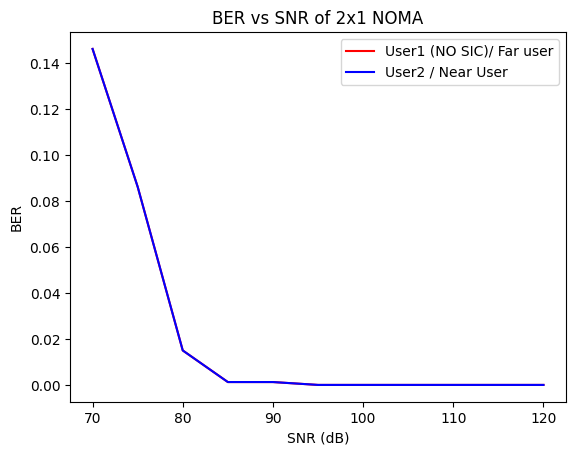

In [ ]:
plt.plot(SNR_db, BER_u1, color='r', label='User1 (NO SIC)/ Far user')
plt.plot(SNR_db, BER_u2, color='b', label='User2 / Near User')
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
#plt.ylim(0, 0.5)
plt.title("BER vs SNR of 2x1 NOMA")
plt.legend()
plt.show()

In [ ]:
#Save the Model
model_u1.save("5x1 U1 model.h5")
print("Saved model to disk")

Saved model to disk


In [ ]:
#Save the Model
model_u2.save("5x1 U2 model.h5")
print("Saved model to disk")

Saved model to disk
